In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import os
import sys
from path import PathFinder

In [2]:
PATHS = PathFinder()
# DIR_OUT = PATHS["DIR_TMP"] / "b0402_out"
DIR_OUT = PATHS["DIR_SRC"] / "out" 
ls_csv = [f for f in (DIR_OUT / "study1").glob("*.csv")] + \
         [f for f in (DIR_OUT / "study2").glob("*.csv")]
ls_csv

Successfully loaded /home/niche/COLO/.env
Available project environments: 
    DIR_SRC=/home/niche/COLO
    DIR_DATA=/home/niche/data/cow-colo
    LIB_PYNICHE=/home/niche/pyniche
    DIR_TMP=/home/niche/data/tmp_colo


[PosixPath('/home/niche/COLO/out/study1/results_5.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_3.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_1.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_6.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_9.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_0.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_2.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_4.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_8.csv'),
 PosixPath('/home/niche/COLO/out/study1/results_7.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_5.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_3.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_1.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_6.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_9.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_0.csv'),
 PosixPath('/home/niche/COLO/out/study2/results_2.csv'),
 PosixPath('/home/niche/COLO/ou

In [3]:
def add_family(df):
    df.loc[:, ["family"]] = "DETR"
    df.loc[df["model"].str.contains("yolo12"), "family"] = "YOLOv12"
    df.loc[df["model"].str.contains("yolo11"), "family"] = "YOLOv11"
    return df
def add_size(df):
    # rtdetr-x, yolo12x, yolo11x
    df.loc[:, ["size"]] = "small"
    df.loc[df["model"].str.contains("yolo11x"), "size"] = "large"
    df.loc[df["model"].str.contains("yolo12x"), "size"] = "large"
    df.loc[df["model"].str.contains("rtdetr-x"), "size"] = "large"
    return df

In [4]:
df_s1 = pd.concat([pd.read_csv(f) for f in ls_csv if "study1" in str(f)], ignore_index=True)
df_s1 = add_family(df_s1)
df_s1 = add_size(df_s1)
n_row = df_s1.shape[0]
n_unique_row = df_s1.loc[:, ["data", "model", "n", "map5095", "map50", "f1"]].drop_duplicates().shape[0]
print(f"Number of rows: {n_row}")
print(f"Number of unique rows: {n_unique_row}")
df_s1

Number of rows: 1383
Number of unique rows: 1383


,data,model,params,n,thread,iter,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp,family,size
0,0_all,yolo12x,59.1,16,5,1,0.3025,0.5739,0.6705,0.5293,0.5916,1160,367,1453,YOLOv12,large
1,0_all,yolo12x,59.1,32,5,1,0.4031,0.7383,0.7299,0.6872,0.7079,1160,320,324,YOLOv12,large
2,0_all,yolo12x,59.1,64,5,1,0.4689,0.8116,0.8291,0.7302,0.7765,1160,215,438,YOLOv12,large
3,0_all,yolo12x,59.1,128,5,1,0.5891,0.8701,0.9053,0.7832,0.8399,1160,262,67,YOLOv12,large
4,0_all,yolo12x,59.1,500,5,1,0.6391,0.9325,0.9020,0.8828,0.8923,1160,118,122,YOLOv12,large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,b_light,yolo11n,2.6,500,7,2,0.5288,0.8278,0.9009,0.7202,0.8005,436,103,62,YOLOv11,small
1379,0_all,yolo12x,59.1,32,7,3,0.4079,0.7181,0.7985,0.6253,0.7014,1160,385,226,YOLOv12,large
1380,0_all,yolo12x,59.1,128,7,3,0.5588,0.8586,0.8984,0.7569,0.8216,1160,256,92,YOLOv12,large
1381,0_all,yolo12x,59.1,500,7,3,0.6313,0.9380,0.9123,0.8638,0.8874,1160,118,149,YOLOv12,large


In [5]:
df_s2 = pd.concat([pd.read_csv(f) for f in ls_csv if "study2" in str(f)], ignore_index=True)
df_s2 = add_family(df_s2)
df_s2 = add_size(df_s2)
n_row = df_s2.shape[0]
n_unique_row = df_s2.loc[:, ["data", "model", "n", "map5095", "map50", "f1"]].drop_duplicates().shape[0]
print(f"Number of rows: {n_row}")
print(f"Number of unique rows: {n_unique_row}")
df_s2

Number of rows: 846
Number of unique rows: 846


,data,pretrain,model,params,n,thread,iter,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp,family,size
0,e_IMU,True,yolo12x,59.1,16,5,1,0.3190,0.6048,0.7277,0.4995,0.5924,808,428,100,YOLOv12,large
1,e_IMU,False,yolo12x,59.1,16,5,1,0.4183,0.7208,0.7726,0.6089,0.6811,808,325,80,YOLOv12,large
2,e_IMU,True,yolo12x,59.1,64,5,1,0.5023,0.7979,0.7799,0.7092,0.7429,808,238,115,YOLOv12,large
3,e_IMU,False,yolo12x,59.1,64,5,1,0.4939,0.7979,0.7950,0.7178,0.7545,808,219,132,YOLOv12,large
4,e_IMU,True,yolo12x,59.1,200,5,1,0.5358,0.8524,0.8855,0.7463,0.8100,808,152,155,YOLOv12,large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,e_IMU,False,rtdetr-x,86.0,16,7,1,0.4081,0.7628,0.8582,0.6815,0.7597,808,169,293,DETR,large
842,e_VT,True,rtdetr-x,86.0,16,7,1,0.4299,0.7794,0.7946,0.7301,0.7610,408,69,331,DETR,large
843,e_VT,False,rtdetr-x,86.0,16,7,1,0.4959,0.8055,0.7973,0.7794,0.7883,408,66,158,DETR,large
844,e_IMU,True,rtdetr-l,45.0,16,7,1,0.4144,0.7618,0.8615,0.6929,0.7681,808,176,296,DETR,small


In [80]:
# count group number
df_s1.query("n==32 and thread == 0").groupby(["data", "model", "n"]).size().reset_index(name="count")

,data,model,n,count
0,0_all,rtdetr-l,32,2
1,0_all,rtdetr-x,32,2
2,0_all,yolo11n,32,1
3,0_all,yolo11x,32,2
4,0_all,yolo12n,32,2
5,0_all,yolo12x,32,2
6,a1_t2s,rtdetr-l,32,2
7,a1_t2s,rtdetr-x,32,2
8,a1_t2s,yolo11n,32,1
9,a1_t2s,yolo11x,32,2


In [82]:
df_s2.query("n==16 and thread == 4 ").groupby(["data", "model", "n", "pretrain"]).size().reset_index(name="count")

,data,model,n,pretrain,count
0,e_IMU,yolo11x,16,False,1
1,e_IMU,yolo11x,16,True,1
2,e_IMU,yolo12x,16,False,1
3,e_IMU,yolo12x,16,True,1
4,e_VT,yolo11x,16,False,1
5,e_VT,yolo11x,16,True,1
6,e_VT,yolo12x,16,False,1
7,e_VT,yolo12x,16,True,1


In [56]:
df_s2.query("n==16").groupby(["data", "model", "n", "pretrain"]).size().reset_index(name="count")

,data,model,n,pretrain,count
0,e_IMU,rtdetr-x,16,False,5
1,e_IMU,rtdetr-x,16,True,5
2,e_IMU,yolo11x,16,False,15
3,e_IMU,yolo11x,16,True,15
4,e_IMU,yolo12x,16,False,19
5,e_IMU,yolo12x,16,True,22
6,e_VT,yolo11x,16,False,14
7,e_VT,yolo11x,16,True,15
8,e_VT,yolo12x,16,False,17
9,e_VT,yolo12x,16,True,17


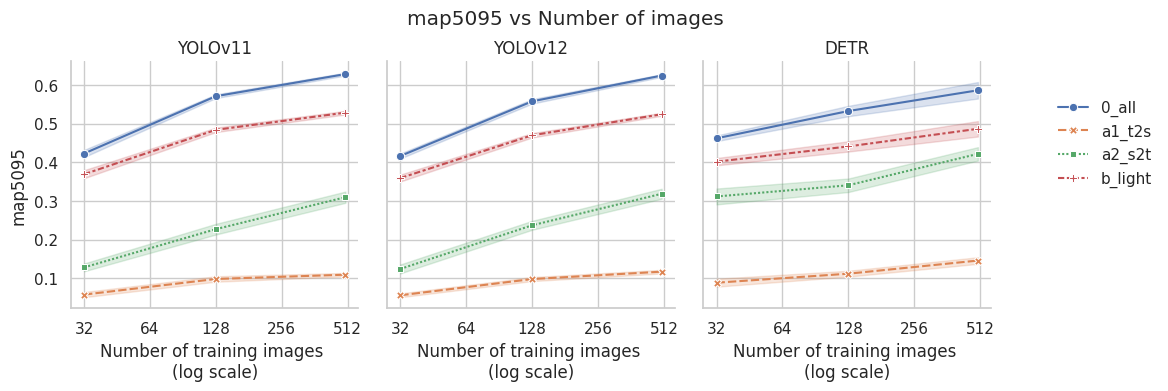

In [115]:
config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
sns.set(style="whitegrid")
df_s1 = df_s1.query("n != 16 and n != 64")

def plot_s1_overview(df, metric):
    g = sns.FacetGrid(df, 
        col="family", col_order=["YOLOv11", "YOLOv12", "DETR"],
        sharey="row",margin_titles=True, 
        # height=6, aspect=1.2
        )
    g.map_dataframe(sns.lineplot, 
        x="n", y=metric, hue="data", style="data",
        err_style="band", errorbar=("se", 2),
        markers=True,)
    g.set(
        xscale="log",
        xticks=[2**i for i in range(5, 10)],
        xticklabels=[2**i for i in range(5, 10)],
        xlabel="Number of training images \n(log scale)",)
    # set bbox to relative x, y to axis
    g.add_legend(bbox_to_anchor=(1, .5), loc='lower right')
    g.set_titles(col_template="{col_name}")
    g.figure.set_size_inches(12, 4)
    # set 10% space above the plot, 20% space between rows, and 10% space between columns
    g.figure.subplots_adjust(top=0.85, hspace=0.2, wspace=0.1)
    g.fig.suptitle(f"{metric} vs Number of images")

plot_s1_overview(df_s1, "map5095")


Text(0.5, 0.98, 'mAP@0.5:0.95 vs Number of images')

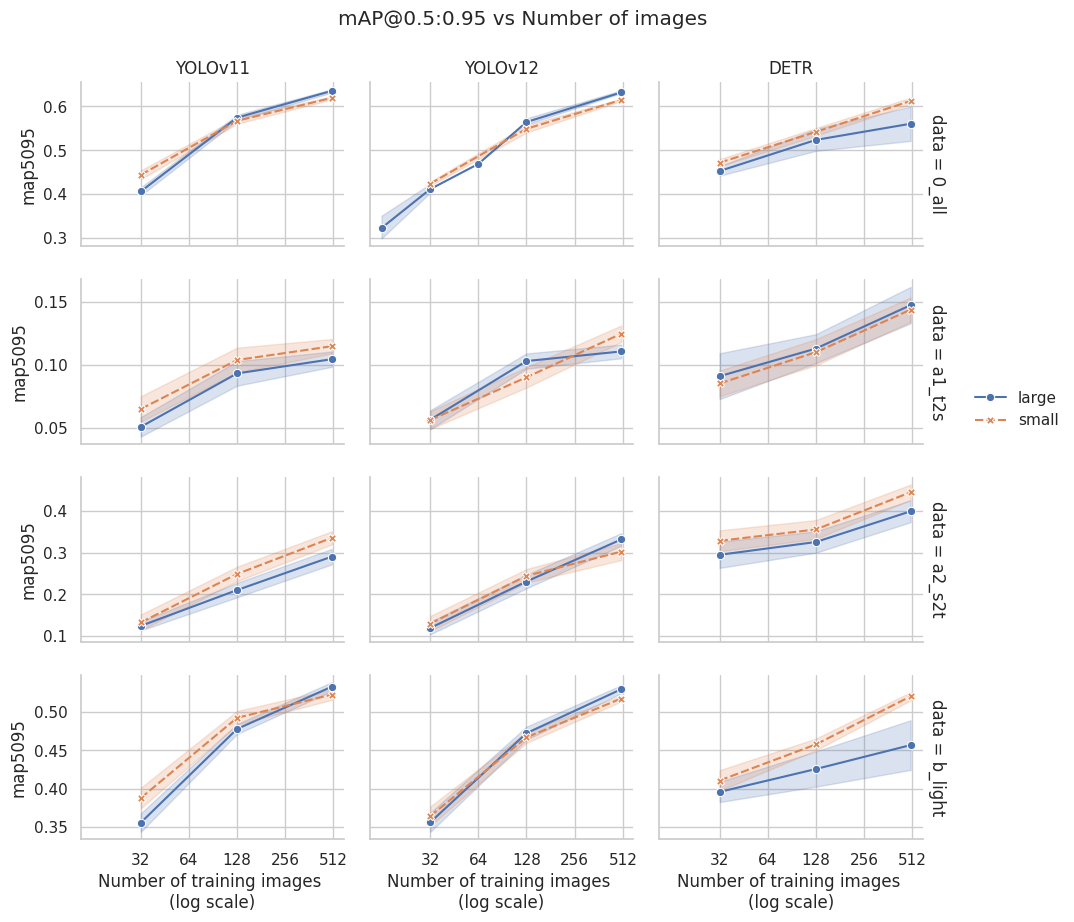

In [14]:
config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
sns.set(style="whitegrid")
g = sns.FacetGrid(df_s1, 
    col="family", col_order=["YOLOv11", "YOLOv12", "DETR"],
    row="data", row_order=config_s1, sharey="row",
    margin_titles=True)
g.map_dataframe(sns.lineplot, 
    x="n", y="map5095", hue="size", style="size",
    hue_order=["large", "small"],
    style_order=["large", "small"],
    err_style="band", errorbar=("se", 2),
    markers=True,
    )
g.set(
    xscale="log",
    xticks=[2**i for i in range(5, 10)],
    xticklabels=[2**i for i in range(5, 10)],
    xlabel="Number of training images \n(log scale)",)

g.add_legend(bbox_to_anchor=(1, 0.5), loc='lower right')
g.set_titles(col_template="{col_name}")
g.figure.set_size_inches(11, 9)
g.figure.subplots_adjust(top=0.9, hspace=0.2, wspace=0.1)
g.fig.suptitle("mAP@0.5:0.95 vs Number of images")

Text(0.5, 0.98, 'mAP@0.5:0.95 vs Number of images')

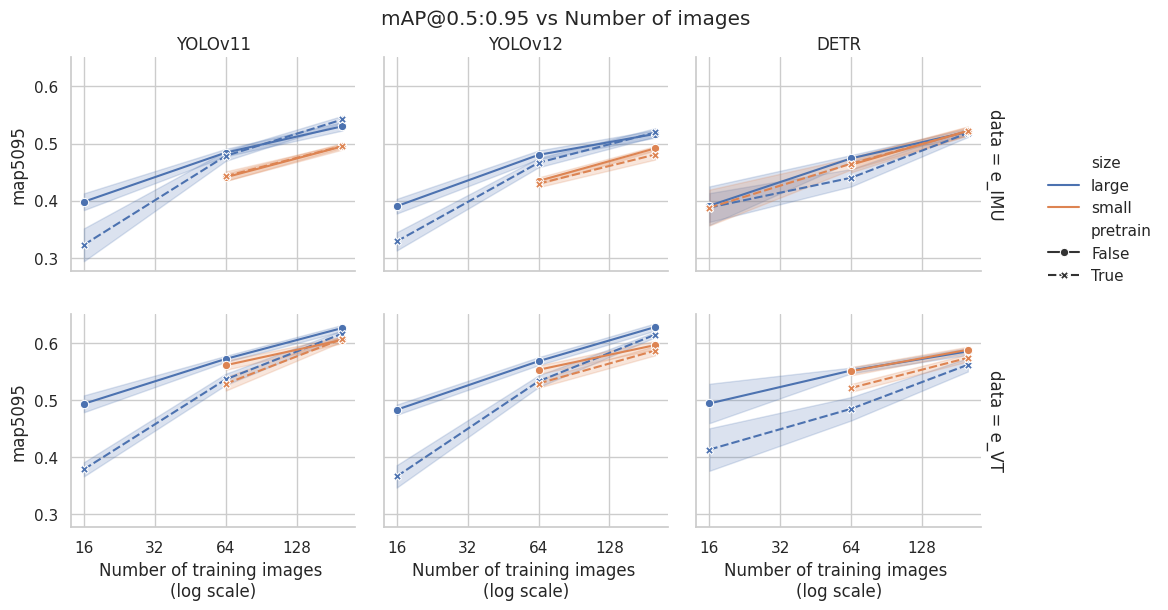

In [128]:
# facet by model
config_ext = ["e_IMU", "e_VT"]

g = sns.FacetGrid(df_s2, 
    row="data", col="family",
    col_order=["YOLOv11", "YOLOv12", "DETR"],
    margin_titles=True)
g.map_dataframe(sns.lineplot, 
    x="n", y="map5095", hue="size", style="pretrain",
    hue_order=["large", "small"],
     # style_order=["True", "False"],
    err_style="band", errorbar=("se", 2),
    markers=True,
    )
# x-axis: 32, 64, 128, 256, 500, in log scale
g.set(
    xscale="log",
    xticks=[2**i for i in range(4, 8)],
    xticklabels=[2**i for i in range(4, 8)],
    xlabel="Number of training images \n(log scale)",)
g.add_legend(bbox_to_anchor=(1, 0.5), loc='lower right')
g.set_titles(col_template="{col_name}")
g.figure.set_size_inches(12, 6)
g.figure.subplots_adjust(top=0.9, hspace=0.2, wspace=0.1)
g.fig.suptitle("mAP@0.5:0.95 vs Number of images")

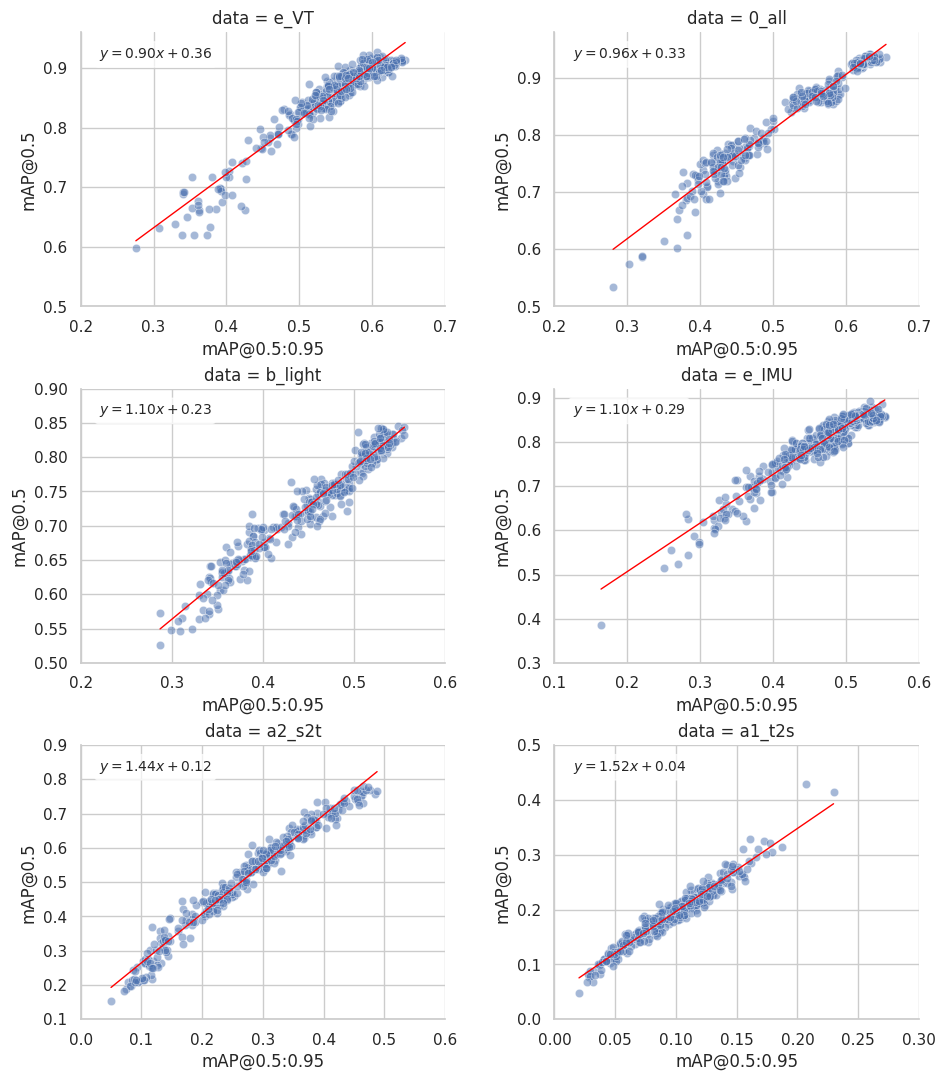

In [63]:
# merge data, family, size, map50, map5095
cols = ["data", "family", "size", "map50", "map5095"]
df_merge = pd.concat(
    [df_s1.loc[:, cols], 
     df_s2.loc[:, cols]],
)
# scatter plot
# hue: data
sns.set(style="whitegrid")
# wrap_col by data
g = sns.FacetGrid(df_merge, 
    sharey=False, sharex=False,
    col="data", col_wrap=2,
    col_order=["e_VT", "0_all",
               "b_light", "e_IMU",
               "a2_s2t", "a1_t2s"],
    margin_titles=True
)
# Map the scatterplot first (with hue)
g.map_dataframe(
    sns.scatterplot,
    x="map5095", y="map50",
    alpha=0.5,
    # edgecolor="black",
    zorder=1,
)

# For each subplot: fit a line, draw it behind dots, and annotate
for ax, (data_key, sub_data) in zip(g.axes.flat, g.facet_data()):
    # Fit line
    x = sub_data["map5095"]
    y = sub_data["map50"]
    if len(x) < 2:  # skip if not enough points
        continue
    slope, intercept = np.polyfit(x, y, deg=1)

    # Create line data for plotting
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = slope * x_vals + intercept

    # Plot the line behind the dots
    ax.plot(x_vals, y_vals, 
            lw=1,
            color="red", zorder=1)  # lower zorder puts line behind

    # Add equation text
    eqn = f"$y = {slope:.2f}x + {intercept:.2f}$"
    ax.text(
        0.05, 0.95, eqn,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
    )

    # Custom ticks at 0.1 intervals
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_rg_min = np.max([0, np.floor(x_min * 10) / 10])
    x_rg_max = np.min([1, np.ceil(x_max * 10) / 10 + 0.1])
    y_rg_min = np.max([0, np.floor(y_min * 10) / 10])
    y_rg_max = np.min([1, np.ceil(y_max * 10) / 10 + 0.1])
    ax.set_xticks(np.arange(x_rg_min, x_rg_max, 0.1))
    ax.set_yticks(np.arange(y_rg_min, y_rg_max, 0.1))
    ax.grid(True)

# Set labels
g.set(
    xscale="linear",
    yscale="linear",
    xlabel="mAP@0.5:0.95",
    ylabel="mAP@0.5",
)
g.figure.set_size_inches(10, 12)
g.figure.subplots_adjust(top=0.9, hspace=0.3, wspace=0.3)

